In [87]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter
import copy

In [88]:
# ── Cell 2: Dataset Path ──────────────────────────────────────────────────────
import kagglehub, os
# Download and get the actual path
base_path = kagglehub.dataset_download("jensdhondt/extendedyaleb-cropped-full")

# Check for both possible folder names in the downloaded path
if 'ExtendedYaleB' in os.listdir(base_path):
    data_dir = os.path.join(base_path, 'ExtendedYaleB')
elif 'cropped' in os.listdir(base_path):
    data_dir = os.path.join(base_path, 'cropped')
else:
    data_dir = base_path

print(f"Using DATA_PATH: {data_dir}")

Using Colab cache for faster access to the 'extendedyaleb-cropped-full' dataset.
Using DATA_PATH: /kaggle/input/extendedyaleb-cropped-full/cropped


In [89]:
# ── Cell 3: Device ────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [90]:
# ── Cell 4: Advanced Transforms for Finetuning ──────────────────────────────
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3))
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [91]:
# ── Cell 5: Dataset Split
train_data_full = datasets.ImageFolder(root=data_dir, transform=train_transform)
test_data_full  = datasets.ImageFolder(root=data_dir, transform=val_transform)

indices = list(range(len(train_data_full)))
labels  = [label for _, label in train_data_full]

train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels, random_state=42)
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_labels, random_state=42)

train_dataset = Subset(train_data_full, train_idx)
val_dataset   = Subset(test_data_full,  val_idx)
test_dataset  = Subset(test_data_full,  test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

classes = train_data_full.classes
print(f"Classes: {len(classes)} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 28 | Train: 11466 | Val: 2457 | Test: 2457


In [92]:
from torchvision import models

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Upgrade to ResNet50 for more capacity
        self.network = models.resnet50(weights='IMAGENET1K_V1')

        # Adapt input for grayscale
        self.network.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Adapt output layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.network(x)

In [93]:
# ── Cell 7: Advanced Finetuning with ResNet50 ──────────────────────
model = CNN(len(classes)).to(device)

# Class weights
labels_list = [label for _, label in train_data_full]
class_counts = Counter(labels_list)
weights = torch.tensor([1.0 / class_counts[i] for i in range(len(classes))]).to(device)
weights = weights / weights.sum() * len(classes)

# Use Label Smoothing to improve test set generalization
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

# Differential Learning Rates
optimizer = optim.Adam([
    {'params': model.network.conv1.parameters(), 'lr': 1e-5},
    {'params': model.network.layer1.parameters(), 'lr': 1e-5},
    {'params': model.network.layer2.parameters(), 'lr': 1e-5},
    {'params': model.network.layer3.parameters(), 'lr': 2e-5},
    {'params': model.network.layer4.parameters(), 'lr': 5e-5},
    {'params': model.network.fc.parameters(), 'lr': 1e-4}
], weight_decay=1e-3)

epochs = 40
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

In [94]:
# ── Cell 8: Training Loop with Best Model Saving ─────────────────────────────
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

best_val_acc  = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    # ── Train ──
    model.train()
    running_loss, correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        correct += (torch.max(outputs, 1)[1] == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / len(train_dataset)

    # ── Validate ──
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss    += criterion(outputs, labels).item()
            val_correct += (torch.max(outputs, 1)[1] == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc  = val_correct / len(val_dataset)

    scheduler.step()

    # ── Save best model ──
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:2d}/{epochs} | Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | LR={scheduler.get_last_lr()[0]:.6f}")

# Restore best weights for evaluation
model.load_state_dict(best_model_wts)
print(f"\nBest Val Acc: {best_val_acc:.4f}")

Epoch  1/40 | Train Acc=0.3653 | Val Acc=0.7314 | LR=0.000010
Epoch  2/40 | Train Acc=0.6927 | Val Acc=0.8759 | LR=0.000009
Epoch  3/40 | Train Acc=0.8050 | Val Acc=0.9153 | LR=0.000008
Epoch  4/40 | Train Acc=0.8587 | Val Acc=0.9463 | LR=0.000007
Epoch  5/40 | Train Acc=0.8883 | Val Acc=0.9577 | LR=0.000005
Epoch  6/40 | Train Acc=0.9143 | Val Acc=0.9642 | LR=0.000003
Epoch  7/40 | Train Acc=0.9286 | Val Acc=0.9658 | LR=0.000002
Epoch  8/40 | Train Acc=0.9345 | Val Acc=0.9735 | LR=0.000001
Epoch  9/40 | Train Acc=0.9437 | Val Acc=0.9719 | LR=0.000000
Epoch 10/40 | Train Acc=0.9465 | Val Acc=0.9740 | LR=0.000010
Epoch 11/40 | Train Acc=0.9176 | Val Acc=0.9687 | LR=0.000010
Epoch 12/40 | Train Acc=0.9278 | Val Acc=0.9703 | LR=0.000010
Epoch 13/40 | Train Acc=0.9412 | Val Acc=0.9768 | LR=0.000009
Epoch 14/40 | Train Acc=0.9459 | Val Acc=0.9788 | LR=0.000009
Epoch 15/40 | Train Acc=0.9567 | Val Acc=0.9796 | LR=0.000009
Epoch 16/40 | Train Acc=0.9623 | Val Acc=0.9813 | LR=0.000008
Epoch 17

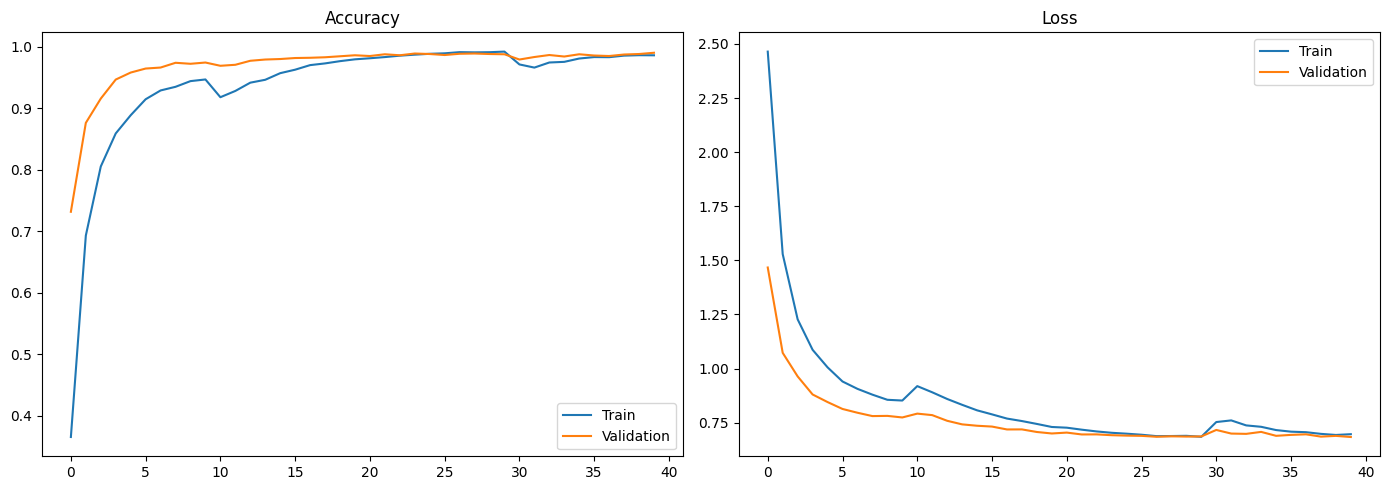

In [95]:
# ── Cell 9: Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_accs, label='Train')
axes[0].plot(val_accs,   label='Validation')
axes[0].set_title("Accuracy"); axes[0].legend()

axes[1].plot(train_losses, label='Train')
axes[1].plot(val_losses,   label='Validation')
axes[1].set_title("Loss"); axes[1].legend()

plt.tight_layout(); plt.show()

Test Accuracy: 0.9812779812779813
              precision    recall  f1-score   support

     yaleB11       1.00      1.00      1.00        87
     yaleB12       1.00      0.98      0.99        88
     yaleB13       0.99      0.99      0.99        88
     yaleB15       0.99      0.99      0.99        88
     yaleB16       0.97      0.98      0.97        87
     yaleB17       1.00      0.98      0.99        88
     yaleB18       1.00      1.00      1.00        88
     yaleB19       0.98      0.99      0.98        88
     yaleB20       0.99      1.00      0.99        88
     yaleB21       0.97      1.00      0.98        87
     yaleB22       0.98      0.99      0.98        88
     yaleB23       1.00      0.95      0.98        88
     yaleB24       0.94      0.97      0.96        88
     yaleB25       0.93      0.94      0.94        87
     yaleB26       0.99      0.98      0.98        88
     yaleB27       0.99      0.99      0.99        87
     yaleB28       1.00      1.00      1.00    

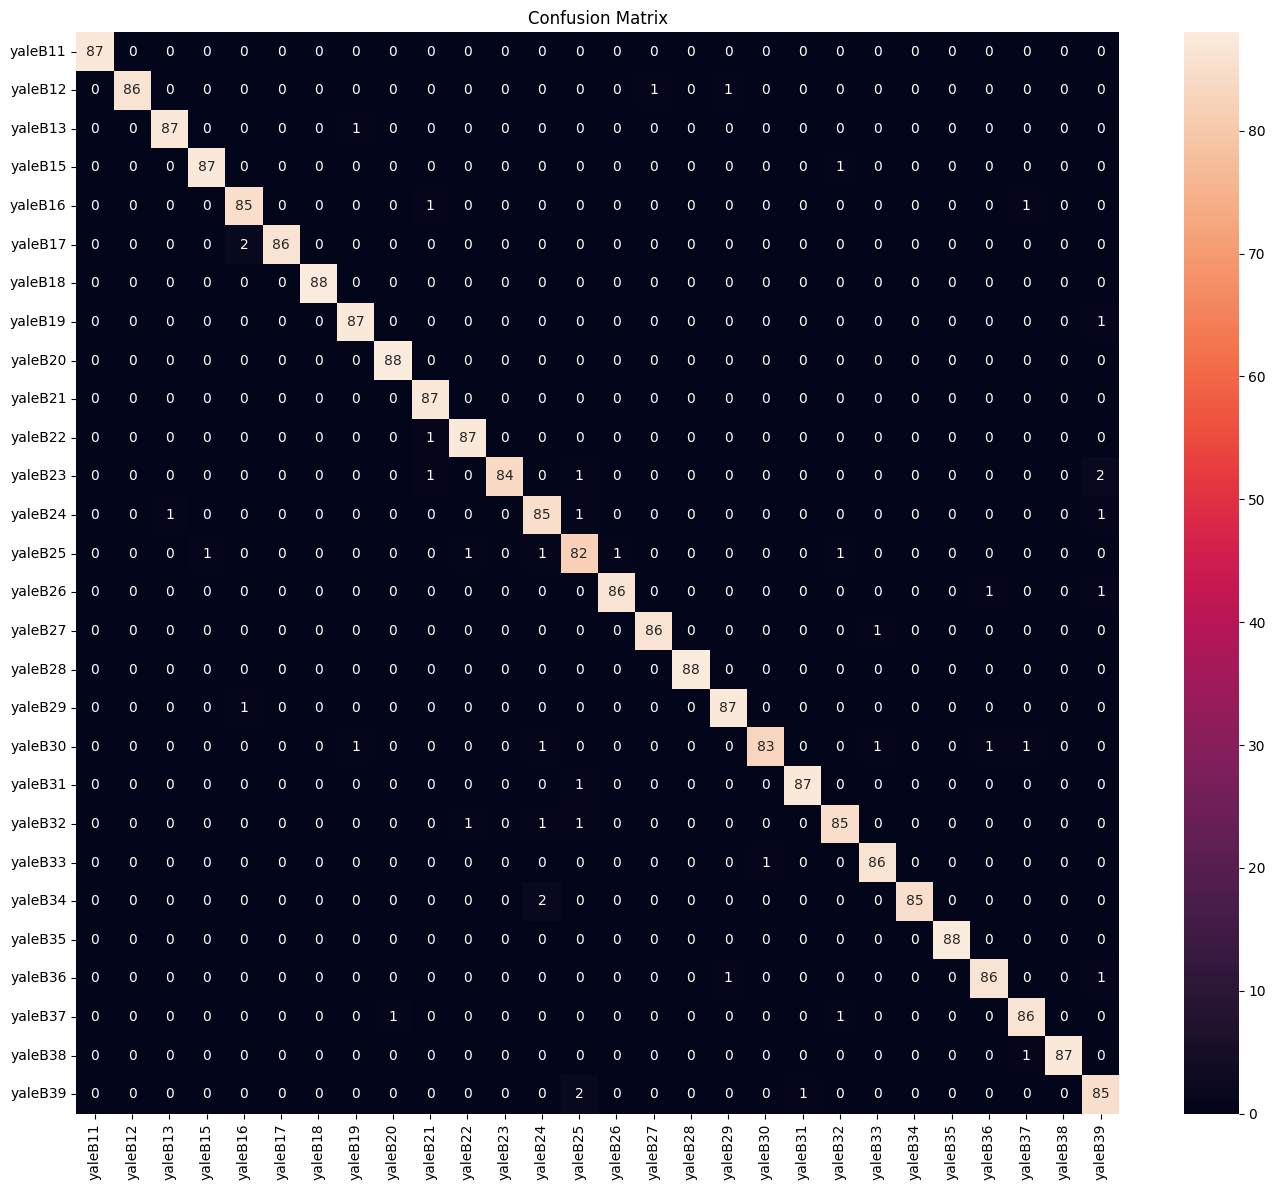

In [96]:
# ── Cell 10: Evaluation on Test Set ──────────────────────────────────────────
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds  = torch.max(model(images), 1)[1]
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

print("Test Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix"); plt.tight_layout(); plt.show()

Test Accuracy: 0.9812779812779813
              precision    recall  f1-score   support

     yaleB11       1.00      1.00      1.00        87
     yaleB12       1.00      0.98      0.99        88
     yaleB13       0.99      0.99      0.99        88
     yaleB15       0.99      0.99      0.99        88
     yaleB16       0.97      0.98      0.97        87
     yaleB17       1.00      0.98      0.99        88
     yaleB18       1.00      1.00      1.00        88
     yaleB19       0.98      0.99      0.98        88
     yaleB20       0.99      1.00      0.99        88
     yaleB21       0.97      1.00      0.98        87
     yaleB22       0.98      0.99      0.98        88
     yaleB23       1.00      0.95      0.98        88
     yaleB24       0.94      0.97      0.96        88
     yaleB25       0.93      0.94      0.94        87
     yaleB26       0.99      0.98      0.98        88
     yaleB27       0.99      0.99      0.99        87
     yaleB28       1.00      1.00      1.00    

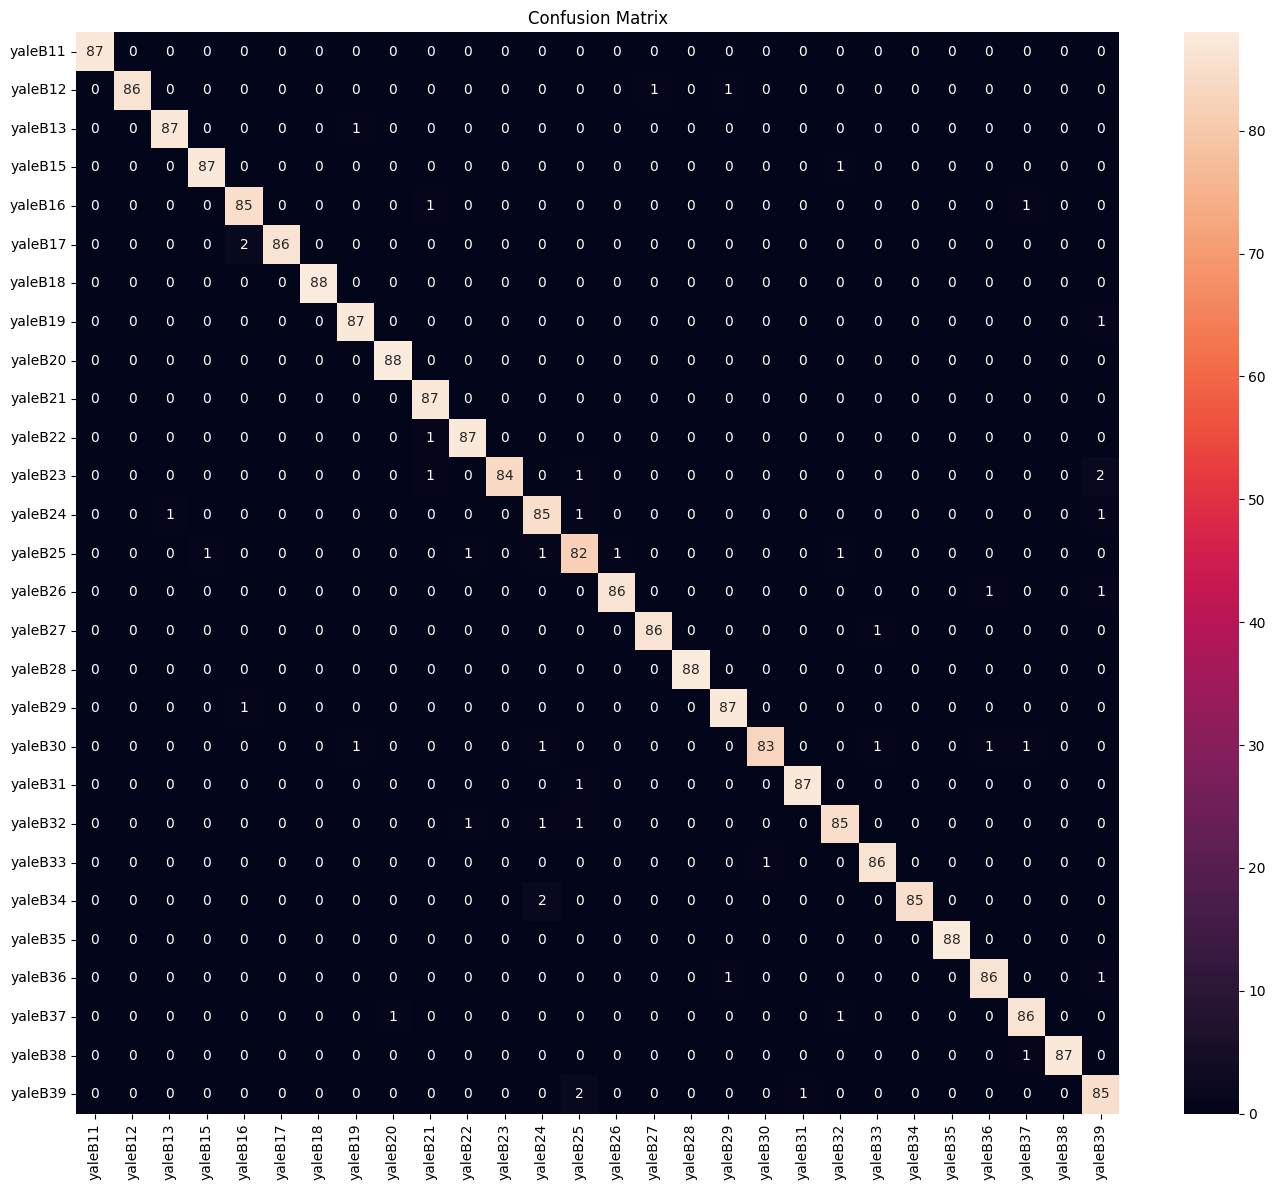

In [97]:
# ── Cell 10: Evaluation on Test Set ──────────────────────────────────────────
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds  = torch.max(model(images), 1)[1]
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

print("Test Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix"); plt.tight_layout(); plt.show()

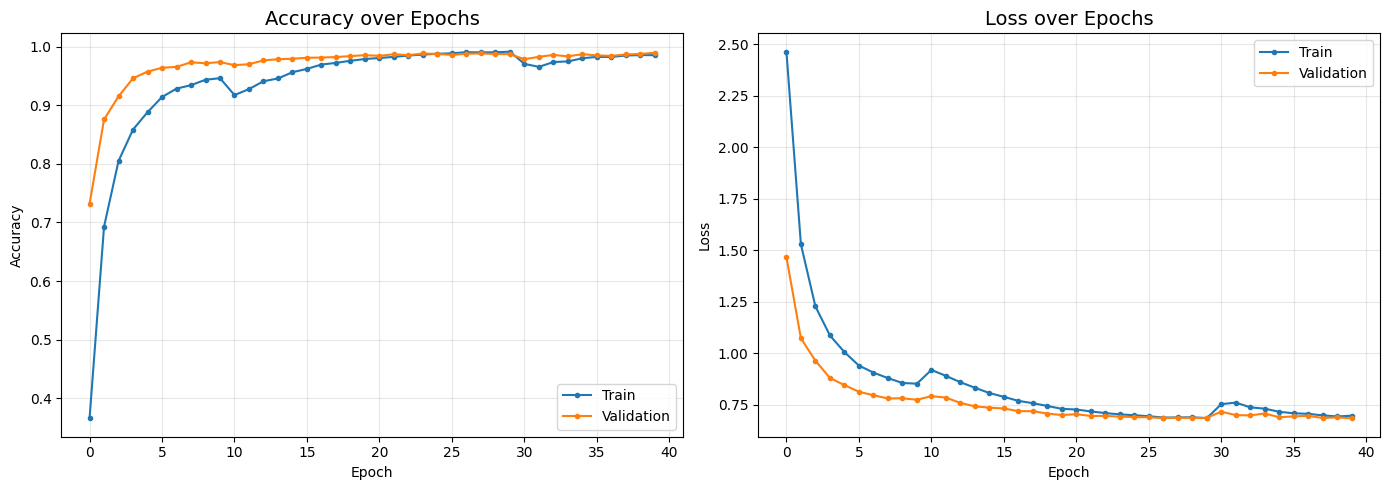

In [98]:
# ── GRAPH 1 & 2: Accuracy and Loss curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_accs, label='Train', marker='o', markersize=3)
axes[0].plot(val_accs, label='Validation', marker='o', markersize=3)
axes[0].set_title("Accuracy over Epochs", fontsize=14)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_losses, label='Train', marker='o', markersize=3)
axes[1].plot(val_losses, label='Validation', marker='o', markersize=3)
axes[1].set_title("Loss over Epochs", fontsize=14)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("accuracy_loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()

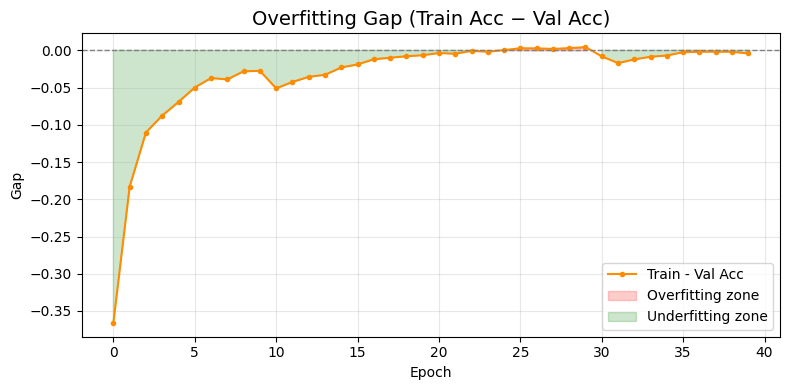

In [99]:
# ── GRAPH 3: Overfitting Gap ──────────────────────────────────────────────────
gap = np.array(train_accs) - np.array(val_accs)

plt.figure(figsize=(8, 4))
plt.plot(gap, color='darkorange', marker='o', markersize=3, label='Train - Val Acc')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.fill_between(range(len(gap)), gap, 0,
                 where=(gap > 0), alpha=0.2, color='red', label='Overfitting zone')
plt.fill_between(range(len(gap)), gap, 0,
                 where=(gap < 0), alpha=0.2, color='green', label='Underfitting zone')
plt.title("Overfitting Gap (Train Acc − Val Acc)", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Gap")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("overfitting_gap.png", dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_466/1431159963.py:8: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  temp_scheduler.step()


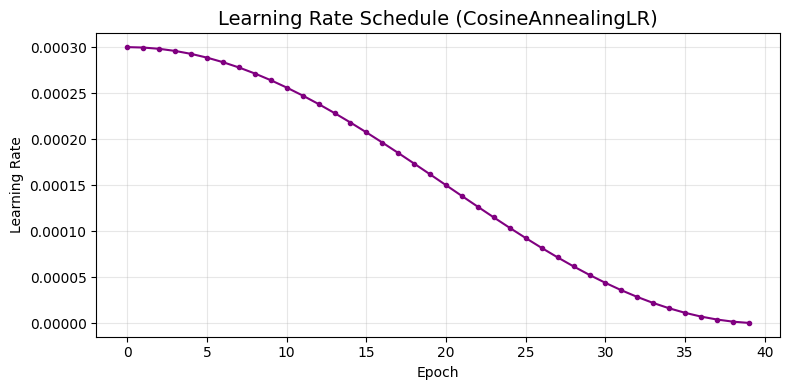

In [100]:
# ── GRAPH 4: Learning Rate over Epochs ───────────────────────────────────────
# (tracks how CosineAnnealingLR decays the LR across epochs)
lrs = []
temp_optimizer = optim.Adam(model.parameters(), lr=3e-4)
temp_scheduler = optim.lr_scheduler.CosineAnnealingLR(temp_optimizer, T_max=40)
for _ in range(40):
    lrs.append(temp_scheduler.get_last_lr()[0])
    temp_scheduler.step()

plt.figure(figsize=(8, 4))
plt.plot(lrs, color='purple', marker='o', markersize=3)
plt.title("Learning Rate Schedule (CosineAnnealingLR)", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lr_schedule.png", dpi=150, bbox_inches='tight')
plt.show()

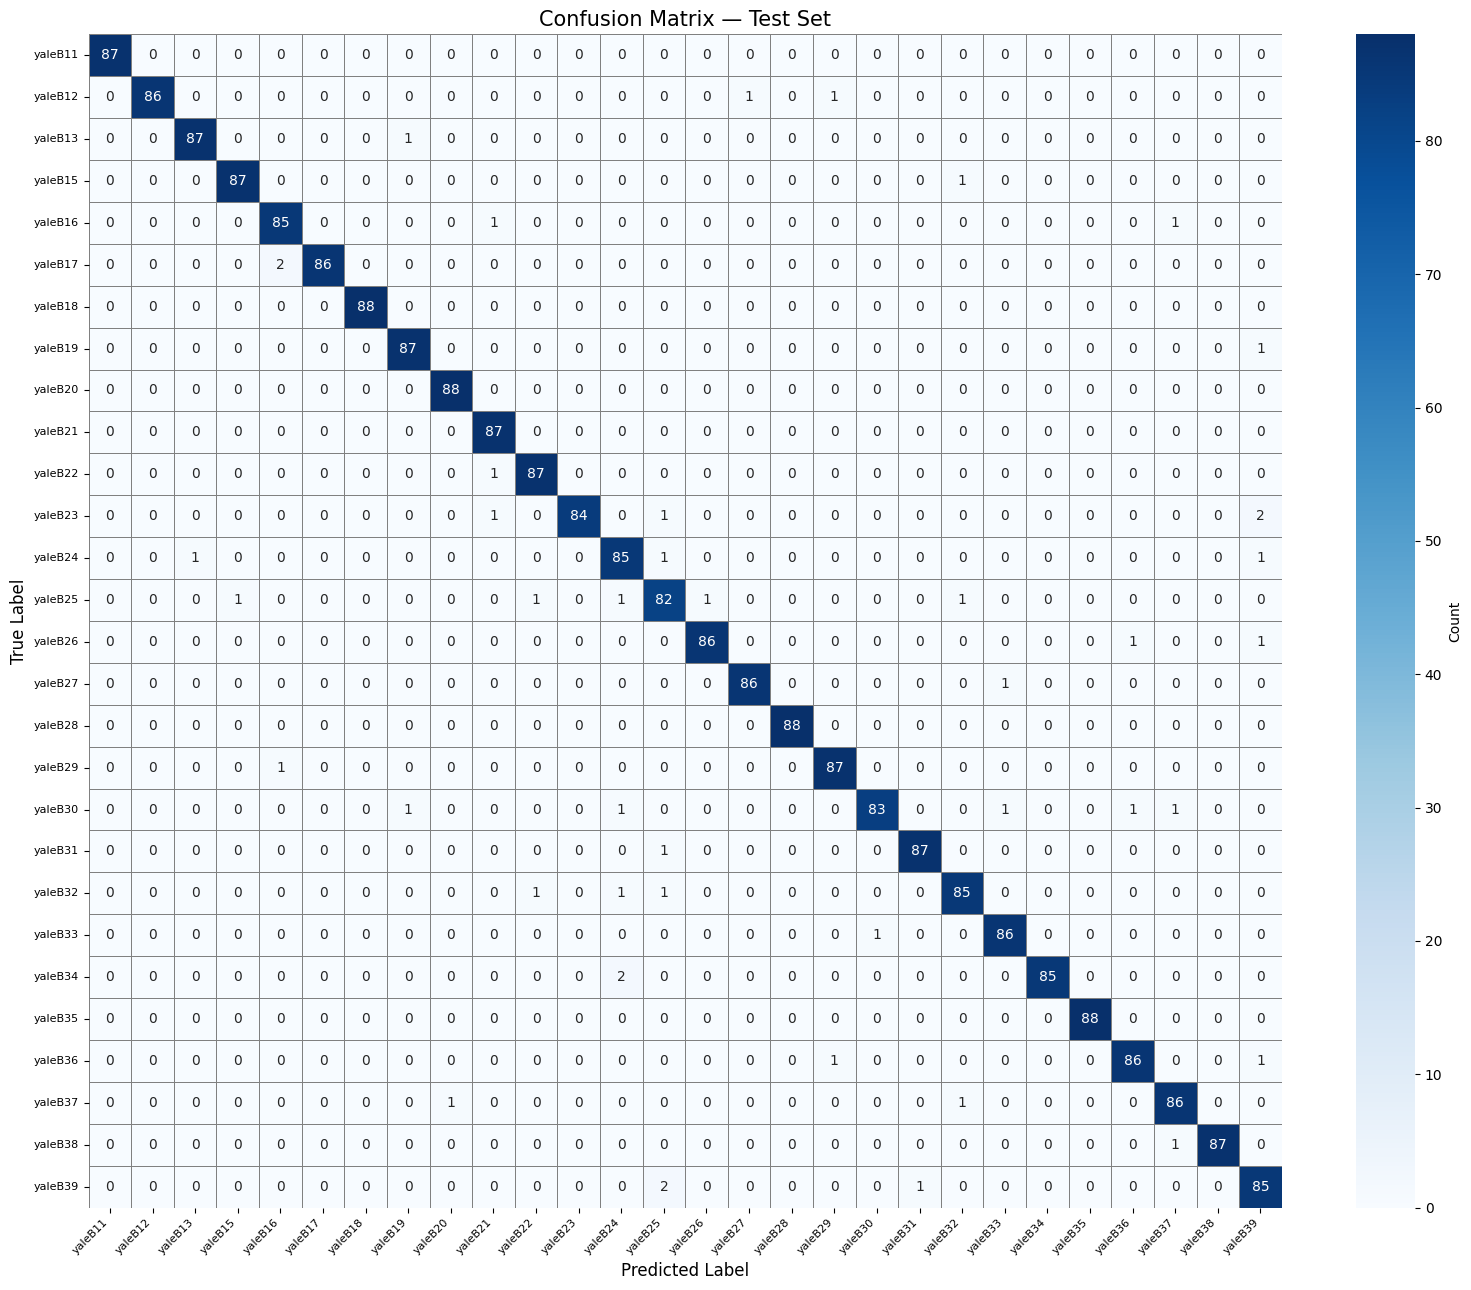

In [101]:
# ── GRAPH 5: Confusion Matrix ─────────────────────────────────────────────────
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Count'})
plt.title("Confusion Matrix — Test Set", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

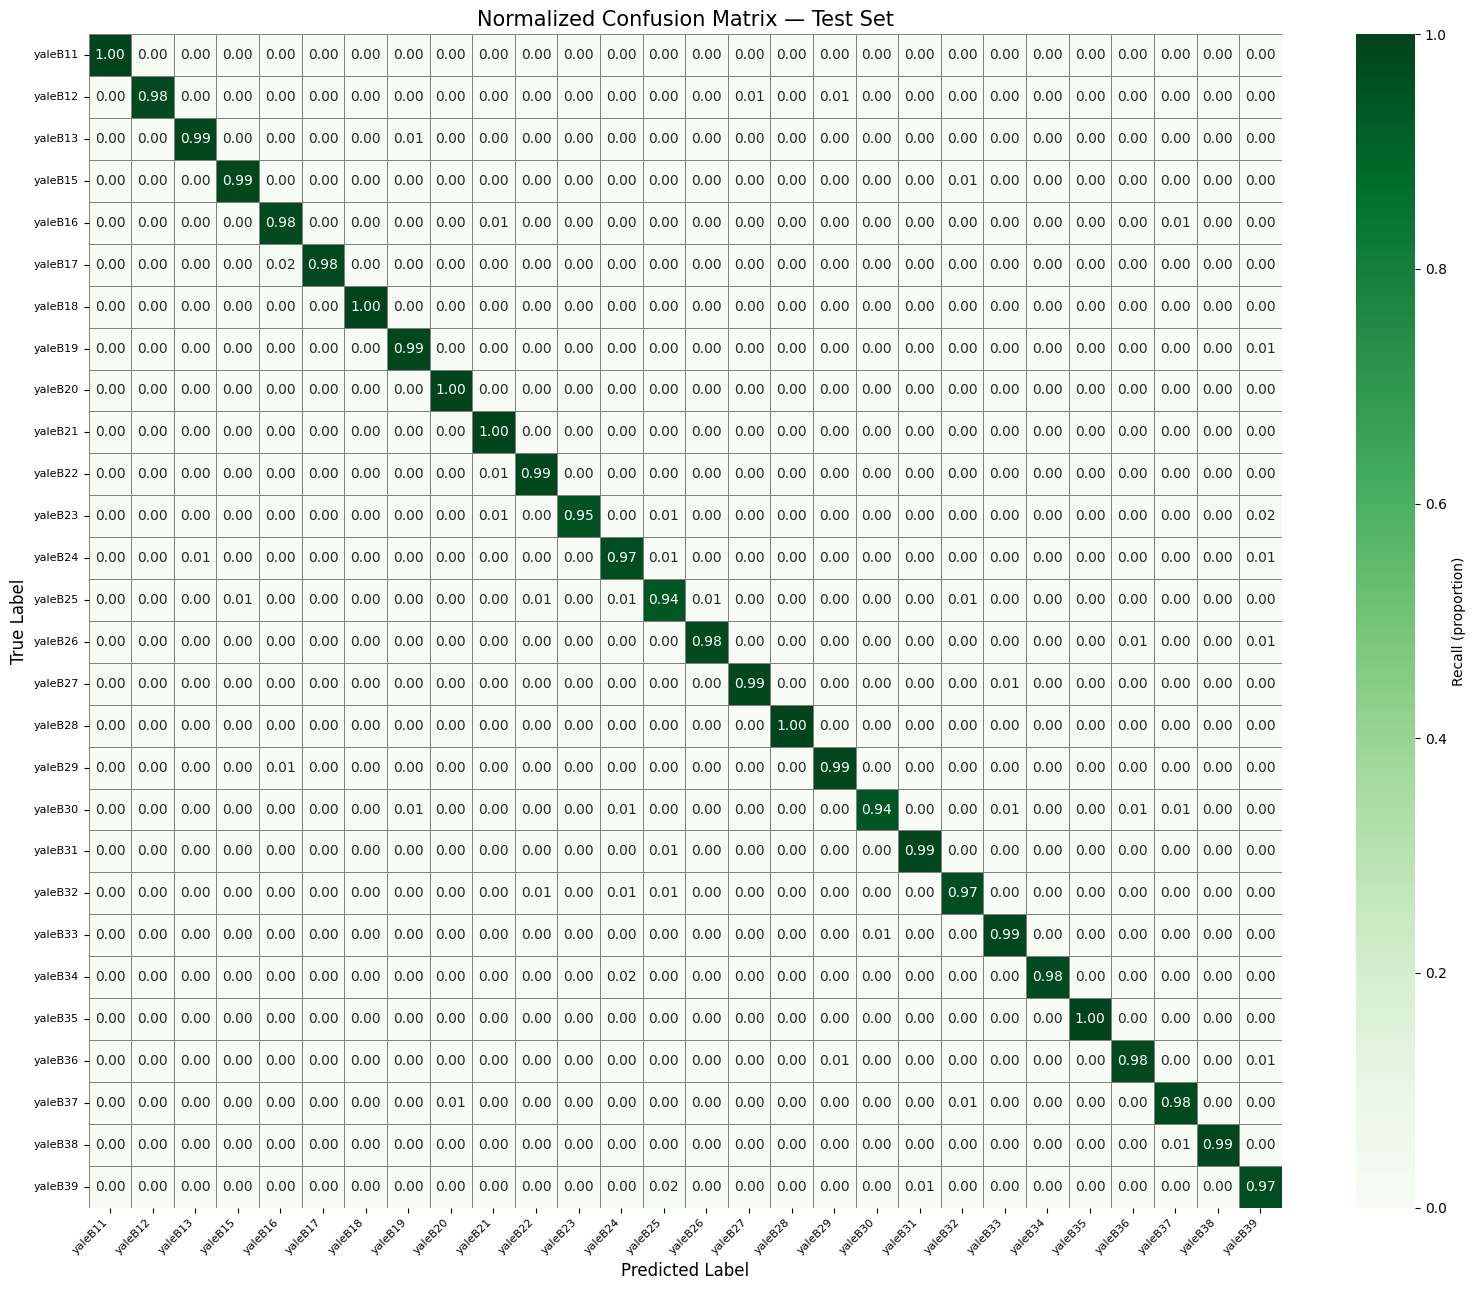

In [102]:
# ── GRAPH 6: Normalized Confusion Matrix ─────────────────────────────────────
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(16, 13))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray',
            vmin=0, vmax=1,
            cbar_kws={'label': 'Recall (proportion)'})
plt.title("Normalized Confusion Matrix — Test Set", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix_normalized.png", dpi=150, bbox_inches='tight')
plt.show()

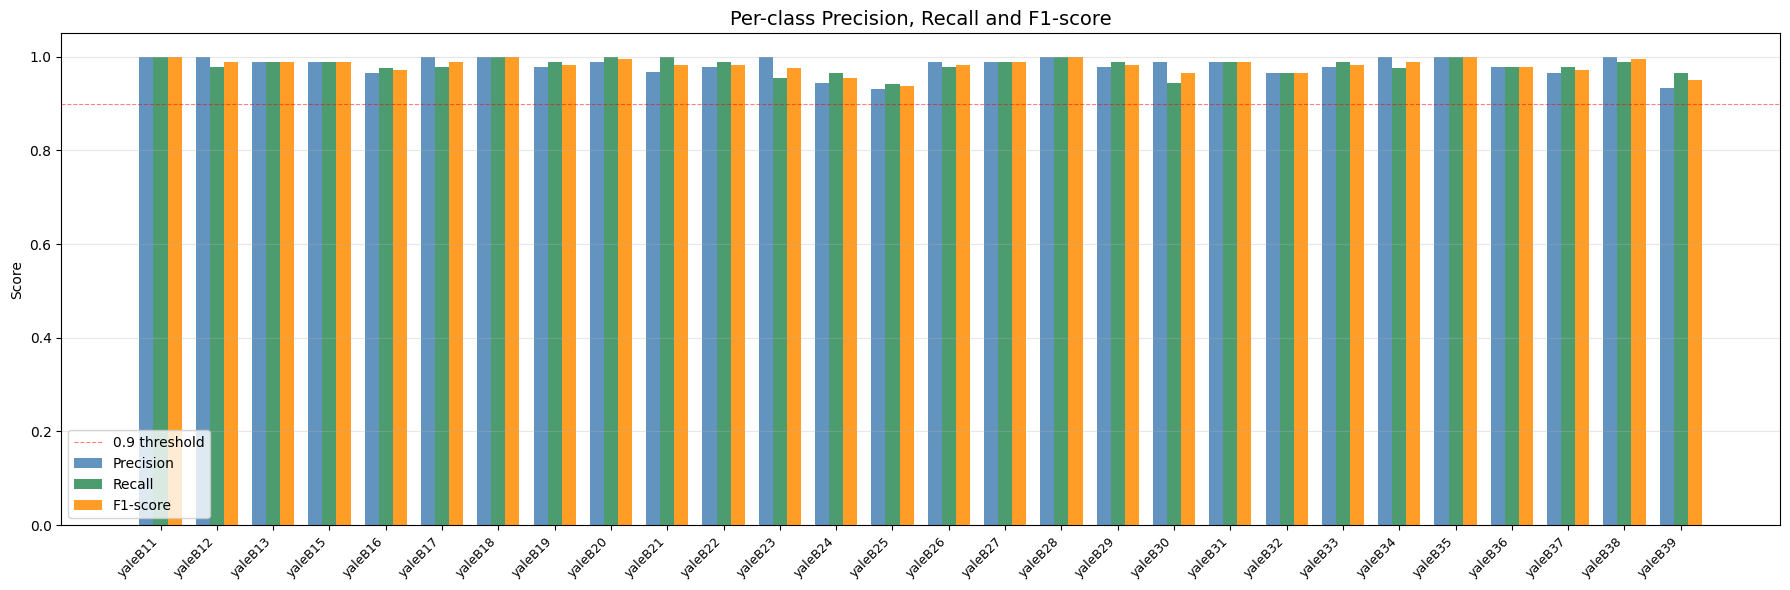

In [103]:
# ── GRAPH 7: Per-class Precision / Recall / F1 ───────────────────────────────
report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)

prec  = [report[c]['precision'] for c in classes]
rec   = [report[c]['recall']    for c in classes]
f1    = [report[c]['f1-score']  for c in classes]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(x - width, prec, width, label='Precision', color='steelblue',  alpha=0.85)
ax.bar(x,         rec,  width, label='Recall',    color='seagreen',   alpha=0.85)
ax.bar(x + width, f1,   width, label='F1-score',  color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-class Precision, Recall and F1-score", fontsize=14)
ax.axhline(0.9, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='0.9 threshold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

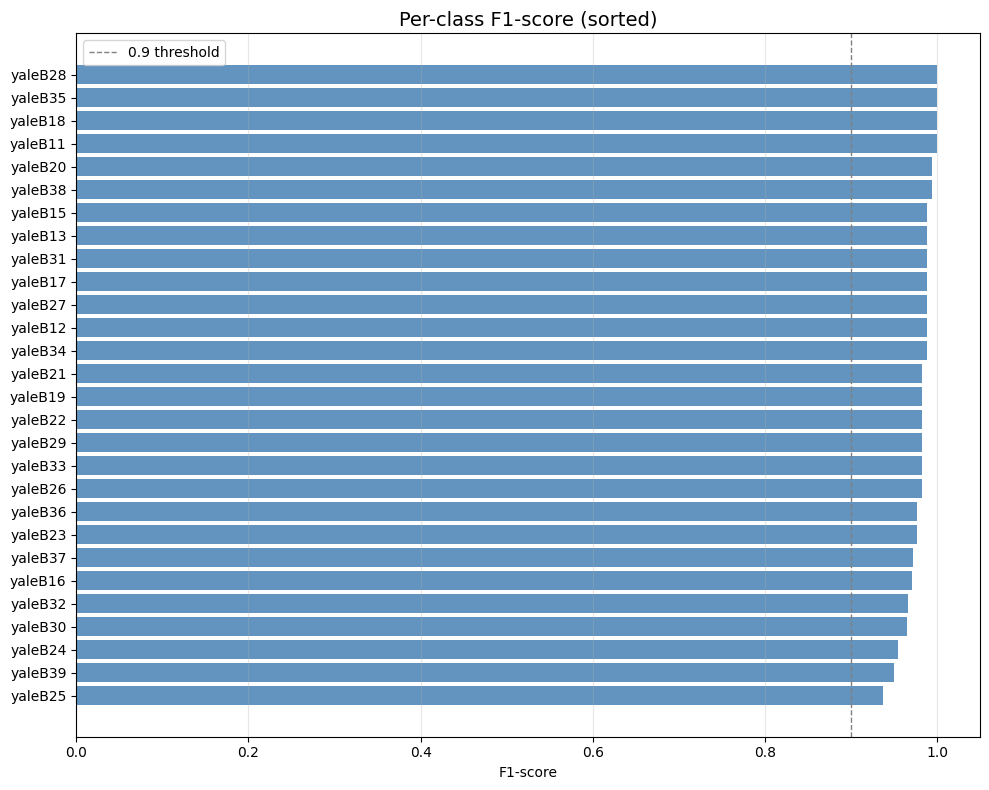

In [104]:
# ── GRAPH 8: Per-class F1 sorted bar ─────────────────────────────────────────
sorted_idx = np.argsort(f1)
sorted_classes = [classes[i] for i in sorted_idx]
sorted_f1 = [f1[i] for i in sorted_idx]
colors = ['red' if v < 0.85 else 'steelblue' for v in sorted_f1]

plt.figure(figsize=(10, 8))
plt.barh(sorted_classes, sorted_f1, color=colors, alpha=0.85)
plt.axvline(0.9, color='gray', linestyle='--', linewidth=1, label='0.9 threshold')
plt.xlabel("F1-score")
plt.title("Per-class F1-score (sorted)", fontsize=14)
plt.xlim(0, 1.05)
plt.legend()
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("f1_sorted.png", dpi=150, bbox_inches='tight')
plt.show()

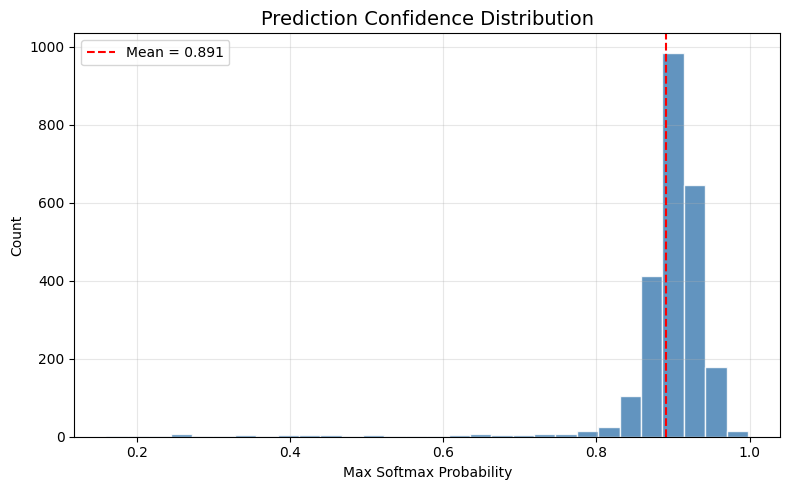

In [105]:
# ── GRAPH 9: Confidence Histogram ────────────────────────────────────────────
confidences = []
model.eval()
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        probs = torch.softmax(model(images), dim=1)
        max_probs, _ = torch.max(probs, 1)
        confidences.extend(max_probs.cpu().numpy())

plt.figure(figsize=(8, 5))
plt.hist(confidences, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(np.mean(confidences), color='red', linestyle='--',
            linewidth=1.5, label=f'Mean = {np.mean(confidences):.3f}')
plt.title("Prediction Confidence Distribution", fontsize=14)
plt.xlabel("Max Softmax Probability")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("confidence_histogram.png", dpi=150, bbox_inches='tight')
plt.show()

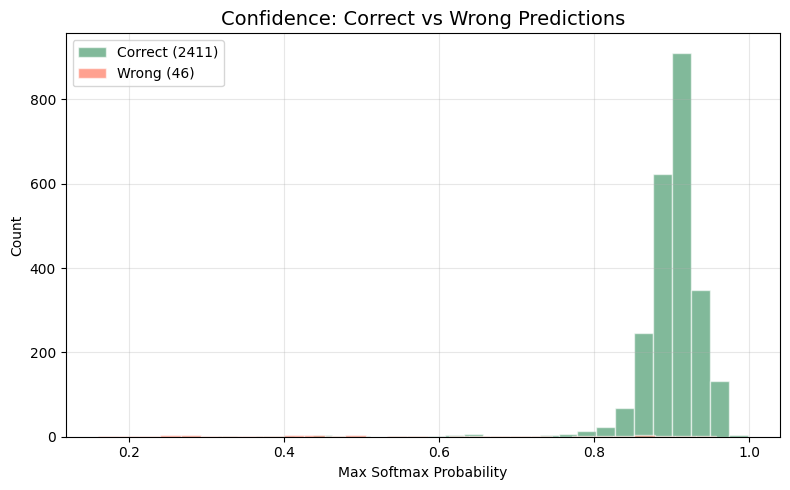

In [106]:
# ── GRAPH 10: Confidence by Correct vs Wrong predictions ─────────────────────
correct_conf, wrong_conf = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, 1)
        for conf, pred, true in zip(max_probs.cpu().numpy(),
                                     preds.cpu().numpy(),
                                     labels.numpy()):
            if pred == true:
                correct_conf.append(conf)
            else:
                wrong_conf.append(conf)

plt.figure(figsize=(8, 5))
plt.hist(correct_conf, bins=30, alpha=0.6, color='seagreen', label=f'Correct ({len(correct_conf)})', edgecolor='white')
plt.hist(wrong_conf,   bins=30, alpha=0.6, color='tomato',   label=f'Wrong ({len(wrong_conf)})',   edgecolor='white')
plt.title("Confidence: Correct vs Wrong Predictions", fontsize=14)
plt.xlabel("Max Softmax Probability")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("confidence_correct_vs_wrong.png", dpi=150, bbox_inches='tight')
plt.show()

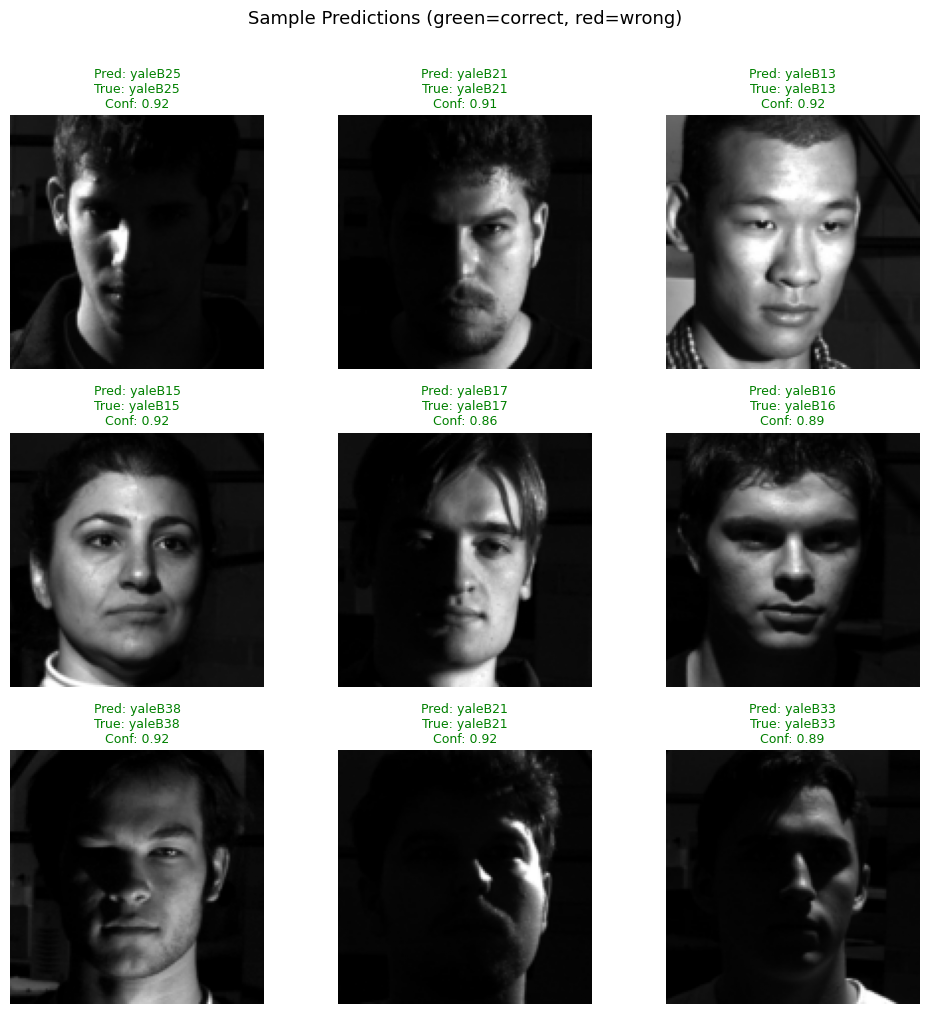

In [107]:
# ── GRAPH 11: Sample predictions (3×3 grid) ──────────────────────────────────
images, labels = next(iter(test_loader))
images = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)
    confs, preds = torch.max(probs, 1)

images = images.cpu()

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    pred_name = classes[preds[i]]
    true_name = classes[labels[i]]
    conf_val  = confs[i].item()
    color = 'green' if preds[i] == labels[i] else 'red'
    ax.set_title(f"Pred: {pred_name}\nTrue: {true_name}\nConf: {conf_val:.2f}",
                 fontsize=9, color=color)
    ax.axis('off')

plt.suptitle("Sample Predictions (green=correct, red=wrong)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

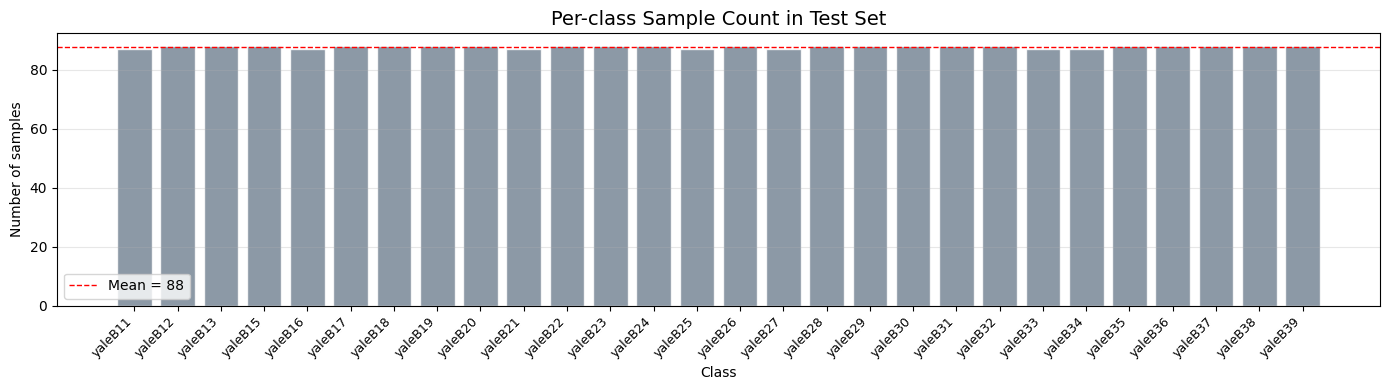

In [108]:
# ── GRAPH 12: Per-class support (sample count in test set) ────────────────────
support = [report[c]['support'] for c in classes]

plt.figure(figsize=(14, 4))
plt.bar(classes, support, color='slategray', alpha=0.8, edgecolor='white')
plt.title("Per-class Sample Count in Test Set", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.axhline(np.mean(support), color='red', linestyle='--',
            linewidth=1, label=f'Mean = {np.mean(support):.0f}')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_support.png", dpi=150, bbox_inches='tight')
plt.show()